## Assignment Machine Learning
 _Authors: Ela, Emma, Florence, Jelle_ 

 _Date: 28-03-2026_

Importing packages 

In [32]:
import pandas as pd
import os
import zipfile

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import loguniform, randint, ttest_ind 
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline, FunctionTransformer

from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from tempfile import mkdtemp
from shutil import rmtree

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cross_decomposition import PLSRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score, roc_auc_score, precision_recall_curve, roc_curve

Basics for all models

In [9]:
scores_dict = {}
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=4)

Load data 

In [10]:
with zipfile.ZipFile("ecg_data.zip","r") as zip_ref:
    zip_ref.extractall("ecg_data")

def load_data():
    this_directory = os.getcwd()
    data = pd.read_csv(os.path.join(this_directory, 'ecg_data/ecg_data.csv'), index_col=0)
    return data

raw_data = load_data()

Data description

In [11]:
print(f'The number of samples: {len(raw_data.index)}')
print(f'The number of columns: {len(raw_data.columns)}')

print(f'The number of NaN values in the entire dataframe: {raw_data.isnull().sum().sum()}')
print(f'The number of samples with label 0: {len(raw_data[raw_data["label"] == 0])}')
print(f'The number of samples with label 1: {len(raw_data[raw_data["label"] == 1])}')
print(f'The percentage of samples with label 0 is thus {len(raw_data[raw_data["label"] == 0])/len(raw_data.index)*100:.2f}%', 
      f'and the percentage with label 1 {len(raw_data[raw_data["label"] == 1])/len(raw_data.index)*100:.2f}%')

The number of samples: 827
The number of columns: 9001
The number of NaN values in the entire dataframe: 0
The number of samples with label 0: 681
The number of samples with label 1: 146
The percentage of samples with label 0 is thus 82.35% and the percentage with label 1 17.65%


Splitting the data in a training and test set

In [12]:
X = raw_data.drop('label', axis=1)
Y = raw_data['label']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=4, stratify=Y)

Preprocessing of data

In [13]:
class VarianceFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.01):
        self.threshold = threshold

    def fit(self, X, y=None):
        self.columns_to_drop_ = [col for col in X.columns if np.var(X[col]) < self.threshold]
        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop_, errors="ignore")


class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.95):
        self.threshold = threshold

    def fit(self, X, y=None):
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.columns_to_drop_ = [col for col in upper.columns if any(upper[col] > self.threshold)]
        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop_, errors="ignore")


class TTestFilter(BaseEstimator, TransformerMixin):
    def __init__(self, alpha=0.05):
        self.alpha = alpha

    def fit(self, X, y):
        if isinstance(y, pd.DataFrame):
            y = y.iloc[:, 0]

        self.columns_to_drop_ = []
        threshold = self.alpha / X.shape[1]  # Bonferroni

        for col in X.columns:
            group0 = X.loc[y == 0, col]
            group1 = X.loc[y == 1, col]
            _, p_value = ttest_ind(group0, group1, nan_policy="omit")

            if p_value > threshold:
                self.columns_to_drop_.append(col)

        return self

    def transform(self, X):
        return X.drop(columns=self.columns_to_drop_, errors="ignore")


pipeline = Pipeline([
    ("variance", VarianceFilter(threshold=0.01)),
    ("correlation", CorrelationFilter(threshold=0.95)),
    ("ttest", TTestFilter(alpha=0.05)),
    ("scaler", RobustScaler())
    ])

pipeline.fit(x_train, y_train)
x_train_preprocessed = pipeline.transform(x_train)
x_test_preprocessed = pipeline.transform(x_test)

#amount of features after preprocessing 
x_train_var = pipeline.named_steps["variance"].transform(x_train)
x_train_corr = pipeline.named_steps["correlation"].transform(x_train_var)
x_train_t = pipeline.named_steps["ttest"].transform(x_train_corr)

print(f"Start amount features: {x_train.shape[1]}")
print(f"After the variance filter: {x_train_var.shape[1]}")
print(f"After the correlation filter: {x_train_corr.shape[1]}")
print(f"After the t-test filter: {x_train_t.shape[1]}")

Start amount features: 9000
After the variance filter: 9000
After the correlation filter: 4068
After the t-test filter: 47


Function for the evaluation metrics on test set (Precision, Recall, F1, PR-AUC, ROC-AUC and plot of PR-AUC and ROC-AUC)

In [15]:
def evaluate_model_on_test(clf, x_test, y_test, name="Model"):
    '''
        Call function as follows:
        - scores_dict.update(evaluate_model_on_test(...))

        Naming convention for models:
        - LR        -->     Logistic Regression
        - RF        -->     Random Forest
        - SVM       -->     Support Vector Machine
        - XGB       -->     XGBoost
        - PLS-DA    -->     Partial Least-Squares Discriminant Analysis
        - NN        -->     Neural Network
        
    '''
    y_pred = clf.predict(x_test)
    if hasattr(clf, 'predict_proba'):
        y_score = clf.predict_proba(x_test)[:, 1]
    else:
        y_score = clf.decision_function(x_test)

    # Calculate metrics
    precision = precision_score(y_test, y_pred, zero_division=1)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_pr = average_precision_score(y_test, y_score)
    auc_roc = roc_auc_score(y_test, y_score)

    # Print results
    print(f"--- Evaluation: {name} ---")
    print(f"Precision:  {precision:.4f}")
    print(f"Recall:     {recall:.4f}")
    print(f"F1-Score:   {f1:.4f}")
    print(f"AUC-PR:     {auc_pr:.4f}")
    print(f"ROC-AUC:    {auc_roc:.4f}")
    print("-" * 30)

    return {name: y_score} #for final plots with all models


Logistic regression model

In [16]:
pipeline_lr = Pipeline([
    ("variance", VarianceFilter(threshold=0.01)),
    ("correlation", CorrelationFilter(threshold=0.95)),
    ("ttest", TTestFilter(alpha=0.05)),
    ('scaler', RobustScaler()),  #data scaling is important for model convergence with the saga solver
    ('classifier', LogisticRegression(
        solver='saga',
        class_weight = 'balanced',
        random_state=4,
        max_iter=5000  # important for convergence
    ))
])

param_dist = {
    'classifier__C': loguniform(1e-3, 10),  
    'classifier__penalty': ['l1', 'l2']
}

random_search = RandomizedSearchCV(
    pipeline_lr,
    param_distributions=param_dist,
    n_iter=50,  # number of random combinations
    cv=kf,
    scoring='average_precision',
    n_jobs=-1,
    random_state=4
)

random_search.fit(x_train, y_train)

print('Best parameters found:\n', random_search.best_params_)
print("Best score:", random_search.best_score_)

Best parameters found:
 {'classifier__C': np.float64(0.004927897727336162), 'classifier__penalty': 'l2'}
Best score: 0.530172882004719


c:\Users\emma_\miniconda3\envs\technical_medicine\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [17]:
param_grid_lr = {
    'classifier__C': [0.001, 0.005, 0.01],
    'classifier__penalty': ['l2']  
}

grid_search_lr = GridSearchCV(pipeline_lr, param_grid_lr, cv=kf, scoring='average_precision', n_jobs=-1)
grid_search_lr.fit(x_train, y_train)

print('Best parameters found:\n', grid_search_lr.best_params_)
print("Best score:", grid_search_lr.best_score_)

Best parameters found:
 {'classifier__C': 0.005, 'classifier__penalty': 'l2'}
Best score: 0.5301564118894906


c:\Users\emma_\miniconda3\envs\technical_medicine\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [18]:
lr_model = grid_search_lr.best_estimator_ 

scores_dict.update(evaluate_model_on_test(lr_model, x_test, y_test, name="LR"))

--- Evaluation: LR ---
Precision:  0.3333
Recall:     0.4828
F1-Score:   0.3944
AUC-PR:     0.4319
ROC-AUC:    0.7173
------------------------------


Random forest model

In [19]:
pipeline_rf = Pipeline([
    ("variance", VarianceFilter(threshold=0.01)),
    ("correlation", CorrelationFilter(threshold=0.95)),
    ("ttest", TTestFilter(alpha=0.05)),
    ("scaler", RobustScaler()),
    ("rf", RandomForestClassifier(random_state=4, class_weight="balanced"))
])

param_dist = {
    "rf__n_estimators": randint(100, 600),
    "rf__max_depth": randint(1, 50),
    "rf__min_samples_split": randint(2, 20),
    "rf__min_samples_leaf": randint(1, 10),
    "rf__max_features": ["sqrt", "log2", None],
    "rf__bootstrap": [True, False]
}

random_search = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=param_dist,
    n_iter=50,
    scoring="average_precision",
    cv=kf,
    n_jobs=-1,
    random_state=4,
    return_train_score=True
)

random_search.fit(x_train, y_train)

print('Best parameters found:\n', random_search.best_params_)
print("Best score:", random_search.best_score_)

Best parameters found:
 {'rf__bootstrap': True, 'rf__max_depth': 10, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 7, 'rf__min_samples_split': 10, 'rf__n_estimators': 546}
Best score: 0.5671855638558977


In [20]:
param_grid_rf = {
    "rf__n_estimators": [500, 550, 600],
    "rf__max_depth": [5, 10, 15],
    "rf__min_samples_split": [5, 10, 15],
    "rf__min_samples_leaf": [2, 7, 12],
    "rf__max_features": ["log2"],
    "rf__bootstrap": [True]
}

grid_search_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=kf, scoring='average_precision', n_jobs=-1)
grid_search_rf.fit(x_train, y_train)

print('Best parameters found:\n', grid_search_rf.best_params_)
print('Best score:', grid_search_rf.best_score_)

Best parameters found:
 {'rf__bootstrap': True, 'rf__max_depth': 15, 'rf__max_features': 'log2', 'rf__min_samples_leaf': 7, 'rf__min_samples_split': 5, 'rf__n_estimators': 500}
Best score: 0.5676374109053277


In [21]:
rf_model = grid_search_rf.best_estimator_ 

scores_dict.update(evaluate_model_on_test(rf_model, x_test, y_test, name="RF"))

--- Evaluation: RF ---
Precision:  0.4500
Recall:     0.3103
F1-Score:   0.3673
AUC-PR:     0.5028
ROC-AUC:    0.7845
------------------------------


Support Vector Machine (SVM)

In [22]:
svm_pipeline = Pipeline([
    ('variance', VarianceFilter(threshold=0.01)),
    ('correlation', CorrelationFilter(threshold=0.95)),
    ('ttest', TTestFilter(alpha=0.05)),
    ('scaler', RobustScaler()),
    ('svm', SVC(probability=True, class_weight='balanced', random_state=4))
])

param_distributions = [
    {
        'svm__kernel': ['rbf', 'sigmoid'],
        'svm__C': loguniform(1e-2, 100),
        'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1]
    },
    {
        'svm__kernel': ['poly'],
        'svm__C': loguniform(1e-2, 10),
        'svm__degree': randint(2, 5)
    },
    {
        'svm__kernel': ['linear'],
        'svm__C': loguniform(1e-2, 100)
    }
]

random_search_svm = RandomizedSearchCV(
    estimator=svm_pipeline,
    param_distributions=param_distributions,
    n_iter=50, 
    scoring='average_precision', 
    cv=kf,
    n_jobs=-1 
)

random_search_svm.fit(x_train, y_train)

print('Best parameters found:\n', random_search_svm.best_params_)
print("Best score:", random_search_svm.best_score_)

Best parameters found:
 {'svm__C': np.float64(0.033866580302013866), 'svm__gamma': 0.01, 'svm__kernel': 'sigmoid'}
Best score: 0.5507183025358914


In [23]:
param_grid_svm = {
    "svm__kernel": ["sigmoid"],
    "svm__gamma": [0.01, 'auto'],
    "svm__C": [0.03, 0.05, 0.01]
}

grid_search_svm = GridSearchCV(svm_pipeline, param_grid_svm, cv=kf, scoring='average_precision', n_jobs=-1)
grid_search_svm.fit(x_train, y_train)

print('Best parameters found:\n', grid_search_svm.best_params_)
print('Best score:', grid_search_svm.best_score_)

Best parameters found:
 {'svm__C': 0.03, 'svm__gamma': 0.01, 'svm__kernel': 'sigmoid'}
Best score: 0.5537815253173239


In [24]:
svm_model = grid_search_svm.best_estimator_ 

scores_dict.update(evaluate_model_on_test(svm_model, x_test, y_test, name="SVM"))

--- Evaluation: SVM ---
Precision:  0.3333
Recall:     0.5517
F1-Score:   0.4156
AUC-PR:     0.4944
ROC-AUC:    0.7327
------------------------------


XGBoost (XGB)

In [25]:
scale_pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum() # because of imbalanced dataset, give more weight to the minority class (label 1) in XGBoost

xgb_pipeline = Pipeline([
    ("variance", VarianceFilter(threshold=0.01)),
    ("correlation", CorrelationFilter(threshold=0.95)),
    ("ttest", TTestFilter(alpha=0.05)),
    ("scaler", RobustScaler()),
    ("xgb", XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=scale_pos_weight_val,
        random_state=4,
        eval_metric='logloss',
        tree_method='hist'
    ))
])

param_distributions = {
    'xgb__learning_rate': loguniform(1e-2,0.5), 
    'xgb__max_depth': randint(2,5),             
    'xgb__n_estimators': randint(100,500),  
    'xgb__subsample': loguniform(0.5, 1.0),     
    'xgb__colsample_bytree': loguniform(0.5, 0.9),   
    'xgb__reg_alpha': loguniform(0.1, 5), #L1 regularization
    'xgb__reg_lambda': randint(1,50) #L2 regularization
}

random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=50,          
    scoring='average_precision', 
    cv=kf,
    random_state=4,
    n_jobs=-1 
)

random_search.fit(x_train, y_train)

print('Best parameters found:\n', random_search.best_params_)
print("Best score:", random_search.best_score_)

Best parameters found:
 {'xgb__colsample_bytree': np.float64(0.6074488991764556), 'xgb__learning_rate': np.float64(0.09376626326183432), 'xgb__max_depth': 2, 'xgb__n_estimators': 154, 'xgb__reg_alpha': np.float64(1.3723888866289522), 'xgb__reg_lambda': 33, 'xgb__subsample': np.float64(0.5157156850230444)}
Best score: 0.5804447115843748


In [ ]:
#this cell was too time-consuming; after 12 hours, it was still running, so we used the results of the random search instead
param_grid_xgb = {
    'xgb__learning_rate': [0.05, 0.1, 0.15], 
    'xgb__max_depth': [1, 2, 3],             
    'xgb__n_estimators': [100, 150, 200],  
    'xgb__subsample': [0.4, 0.5, 0.6],     
    'xgb__colsample_bytree': [0.5, 0.6, 0.7],   
    'xgb__reg_alpha': [1, 1.5, 2], #L1 regularization
    'xgb__reg_lambda': [28, 33, 38] #L2 regularization
}

grid_search_xgb = GridSearchCV(xgb_pipeline, param_grid_xgb, cv=kf, scoring='average_precision', n_jobs=-1)
grid_search_xgb.fit(x_train, y_train)

print('Best parameters found:\n', grid_search_xgb.best_params_)
print('Best score:', grid_search_xgb.best_score_)

KeyboardInterrupt: 

In [27]:
xgb_model = random_search.best_estimator_ 

scores_dict.update(evaluate_model_on_test(xgb_model, x_test, y_test, name="XGB"))

--- Evaluation: XGB ---
Precision:  0.3469
Recall:     0.5862
F1-Score:   0.4359
AUC-PR:     0.5097
ROC-AUC:    0.7906
------------------------------


Partial Least-Squares Discriminant Analysis (PLS-DA)

In [36]:
def squeeze_output(X):
        if isinstance(X, tuple):
            X = X[0]
        return X.reshape(X.shape[0], -1)

pipeline_pls_da = Pipeline([
    ("variance", VarianceFilter(threshold=0.01)),
    ("correlation", CorrelationFilter(threshold=0.95)),
    ("ttest", TTestFilter(alpha=0.05)),
    ("scaler", RobustScaler()),  
    ('pls', PLSRegression(scale=False)),
    ('squeeze', FunctionTransformer(squeeze_output)),
    ('classifier', LogisticRegression(solver='saga', class_weight='balanced', random_state=4, max_iter=5000))  # important for convergence
    ])

param_dist = {
    'pls__n_components': randint(1, 47),
    'classifier__C': loguniform(1e-3, 10),
    'classifier__penalty': ['l1', 'l2']
}

random_search = RandomizedSearchCV(
    pipeline_pls_da,
    param_distributions=param_dist,
    n_iter=50,  # number of random combinations
    cv=kf,
    scoring='average_precision',
    n_jobs=-1,
    random_state=4
)

random_search.fit(x_train, y_train)

print('Best parameters found:\n', random_search.best_params_)
print("Best score:", random_search.best_score_)


c:\Users\emma_\miniconda3\envs\technical_medicine\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
79 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\emma_\miniconda3\envs\technical_medicine\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\emma_\miniconda3\envs\technical_medicine\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\emma_\miniconda3\envs\techn

Best parameters found:
 {'classifier__C': np.float64(0.0021514759229678067), 'classifier__penalty': 'l2', 'pls__n_components': 11}
Best score: 0.5354847808846687


c:\Users\emma_\miniconda3\envs\technical_medicine\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [37]:
param_grid_pls_da = {
    'pls__n_components': [5, 10, 15],
    'classifier__C': [0.0005, 0.001, 0.005],
    'classifier__penalty': ['l2']
    }

grid_search_pls_da = GridSearchCV(pipeline_pls_da, param_grid_pls_da, cv=kf, scoring="average_precision", n_jobs=-1)
grid_search_pls_da.fit(x_train, y_train)

print('Best parameters found:\n', grid_search_pls_da.best_params_)
print("Beste score:", grid_search_pls_da.best_score_)

Best parameters found:
 {'classifier__C': 0.001, 'classifier__penalty': 'l2', 'pls__n_components': 10}
Beste score: 0.535331425174565


c:\Users\emma_\miniconda3\envs\technical_medicine\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [38]:
pls_da_model = grid_search_pls_da.best_estimator_ 

scores_dict.update(evaluate_model_on_test(pls_da_model, x_test, y_test, name="PLS-DA"))

--- Evaluation: PLS-DA ---
Precision:  0.3421
Recall:     0.4483
F1-Score:   0.3881
AUC-PR:     0.4025
ROC-AUC:    0.7128
------------------------------


Feed-forward neural network

In [39]:
pipeline_NN = Pipeline(steps=[
    ("variance", VarianceFilter(threshold=0.01)),
    ("correlation", CorrelationFilter(threshold=0.95)),
    ("ttest", TTestFilter(alpha=0.05)),
    ('scaler', RobustScaler()),
    ('classifier', MLPClassifier(early_stopping=True, random_state=4)) 
])

param_grid_NN = {
    'classifier__hidden_layer_sizes': [(5,), (25,),(50,),(25, 12),(50, 25)],
    'classifier__activation': ['relu', 'tanh'],
    'classifier__solver': ['adam', 'sgd', 'lbfgs'],  
    'classifier__learning_rate_init': loguniform(1e-4, 1e-2),
    'classifier__alpha': loguniform(1e-5, 1e-2),
    'classifier__max_iter': randint(150, 500),
}

random_search_NN = RandomizedSearchCV(
    pipeline_NN,
    param_distributions=param_grid_NN,
    n_iter=50,  # number of random combinations
    cv=kf,
    scoring='average_precision',
    n_jobs=-1,
    random_state=4
)

random_search_NN.fit(x_train, y_train)

print('Best parameters found:\n', random_search_NN.best_params_)
print("Best score:", random_search_NN.best_score_)

Best parameters found:
 {'classifier__activation': 'tanh', 'classifier__alpha': np.float64(0.00028393074048748513), 'classifier__hidden_layer_sizes': (50,), 'classifier__learning_rate_init': np.float64(0.008015688671463602), 'classifier__max_iter': 463, 'classifier__solver': 'adam'}
Best score: 0.4967792531856798


In [40]:
param_grid_NN = {
    'classifier__hidden_layer_sizes': [(50,)],
    'classifier__activation': ['tanh'],
    'classifier__solver': ['adam'],
    'classifier__learning_rate_init': [1e-2, 5e-3, 8e-3],
    'classifier__alpha': [3e-4, 1e-4, 5e-4],
    'classifier__learning_rate': ['constant'],
    'classifier__max_iter': [450, 425, 475]
}

grid_search_NN = GridSearchCV(pipeline_NN, param_grid_NN, cv=kf, scoring='average_precision', n_jobs=-1)
grid_search_NN.fit(x_train, y_train)

print('Best parameters found:\n', grid_search_NN.best_params_)
print("Best score:", grid_search_NN.best_score_)

Best parameters found:
 {'classifier__activation': 'tanh', 'classifier__alpha': 0.0003, 'classifier__hidden_layer_sizes': (50,), 'classifier__learning_rate': 'constant', 'classifier__learning_rate_init': 0.01, 'classifier__max_iter': 450, 'classifier__solver': 'adam'}
Best score: 0.5163382352072251


In [41]:
NN_model = grid_search_NN.best_estimator_ 

scores_dict.update(evaluate_model_on_test(NN_model, x_test, y_test, name="NN"))

--- Evaluation: NN ---
Precision:  0.3913
Recall:     0.3103
F1-Score:   0.3462
AUC-PR:     0.3768
ROC-AUC:    0.7236
------------------------------


Precision-recall curve of all models

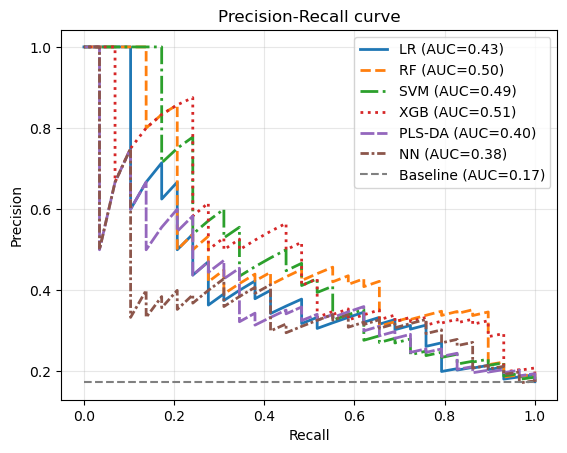

In [48]:
def plot_pr_auc(labels, scores_dict):
    y_true = labels.values.ravel()
    baseline = np.mean(y_true)

    plt.figure()

    linestyles = ['-', '--', '-.', ':', (0, (5, 1)), (0, (3, 1, 1, 1))]
    
    for i, (name, probs) in enumerate(scores_dict.items()):
        precision, recall, _ = precision_recall_curve(y_true, probs)
        auc = average_precision_score(y_true, probs)

        plt.plot(
            recall,
            precision,
            linestyle=linestyles[i % len(linestyles)],
            linewidth=2,
            label=f'{name} (AUC={auc:.2f})'
        )

    plt.hlines(
        baseline, 0, 1,
        colors='grey',
        linestyles='dashed',
        linewidth=1.5,
        label=f'Baseline (AUC={baseline:.2f})'
    )

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_pr_auc(y_test, scores_dict)

Receiver operating characteristic curve for all models 

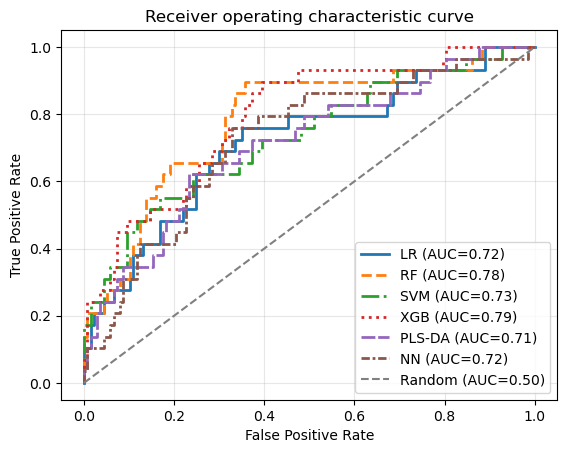

In [46]:
def plot_roc_auc(labels, scores_dict):
    y_true = labels.values.ravel()

    plt.figure()

    linestyles = ['-', '--', '-.', ':', (0, (5, 1)), (0, (3, 1, 1, 1))]
    
    for i, (name, probs) in enumerate(scores_dict.items()):
        fpr, tpr, _ = roc_curve(y_true, probs)
        auc = roc_auc_score(y_true, probs)

        plt.plot(
            fpr,
            tpr,
            linestyle=linestyles[i % len(linestyles)],
            linewidth=2,
            label=f'{name} (AUC={auc:.2f})'
        )

    plt.plot(
        [0, 1], [0, 1],
        color='grey',
        linestyle='dashed',
        linewidth=1.5,
        label='Random (AUC=0.50)' #baseline for a random classifier
    )

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver operating characteristic curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_roc_auc(y_test, scores_dict)